In [8]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
import math
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import KFold, cross_val_score, cross_val_predict, train_test_split
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, roc_curve, auc

In [2]:
data = pd.read_csv('Titanic-Dataset.csv')

In [3]:
X = data.drop(columns=['Survived'])
y = data['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.15, random_state=42)

numeric_features = ['Age', 'Fare']
X_train[numeric_features] = X_train[numeric_features].fillna(X_train[numeric_features].median())
X_test[numeric_features] = X_test[numeric_features].fillna(X_test[numeric_features].median())

sc = StandardScaler()
X_train[numeric_features] = sc.fit_transform(X_train[numeric_features])
X_test[numeric_features] = sc.transform(X_test[numeric_features])

categorical_features = ['Sex', 'Embarked']
X_train[categorical_features] = X_train[categorical_features].fillna(X_train[categorical_features].mode().iloc[0])
X_test[categorical_features] = X_test[categorical_features].fillna(X_train[categorical_features].mode().iloc[0])

X_train = pd.get_dummies(X_train, columns = categorical_features, dtype=int, drop_first = True)
X_test = pd.get_dummies(X_test, columns = categorical_features, dtype=int, drop_first = True)

X_train.drop(columns = ['Name', 'PassengerId',  'Cabin','SibSp', 'Parch', 'Ticket'], inplace = True)
X_test.drop(columns = ['Name', 'PassengerId',  'Cabin','SibSp', 'Parch', 'Ticket'], inplace = True)

In [10]:
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = LogisticRegression(penalty = 'l2', solver = 'liblinear', random_state = 42)
scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy')
print(f'Cross-validation accuracy scores with L2 penalty: {scores}')
print(f'Average Accuracy with L2 penalty: {np.mean(scores):.4f}')

model.fit(X_train, y_train)
test_accuracy = model.score(X_test, y_test)
print(f"Test set accuracy with L2 penalty: {test_accuracy:.4f}")


train_accuracy = model.score(X_train, y_train)
print(f"Train set accuracy with L2 penalty: {train_accuracy:.4f}")

y_pred = model.predict(X_test)
cm = confusion_matrix(y_test, y_pred)
print("Precision score is", precision_score(y_test, y_pred))
print("Recall score is", recall_score(y_test, y_pred))
print("F1 Score is", f1_score(y_test, y_pred))

Cross-validation accuracy scores with L2 penalty: [0.80921053 0.77631579 0.78807947 0.8013245  0.74834437]
Average Accuracy with L2 penalty: 0.7847
Test set accuracy with L2 penalty: 0.8060
Train set accuracy with L2 penalty: 0.7952
Precision score is 0.7884615384615384
Recall score is 0.7321428571428571
F1 Score is 0.7592592592592593


ROC AUC: 0.87


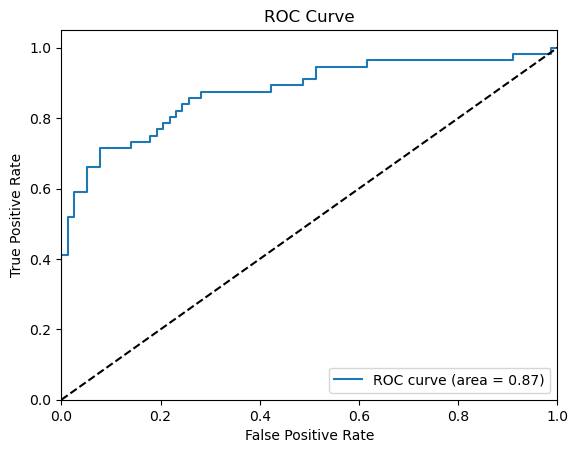

In [11]:
#Q1) Plot the ROC curve on your Titanic model and calculate AUC
fpr, tpr, _ = roc_curve(y_test, model.predict_proba(X_test)[:,1])
roc_auc = auc(fpr, tpr)
print('ROC AUC: %0.2f' % roc_auc)

plt.figure()
plt.plot(fpr, tpr, label='ROC curve (area = %0.2f)' % roc_auc)
plt.plot([0, 1], [0, 1], 'k--')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve')
plt.legend(loc="lower right")
plt.show()

In [21]:
#Q2) Manually change the classification threshold from 0.5 to 0.3 — what happens to precision and recall?
kf = KFold(n_splits=5, shuffle=True, random_state=42)
model = LogisticRegression(penalty = 'l2', solver = 'liblinear', random_state = 42)
scores = cross_val_score(model, X_train, y_train, cv=kf, scoring='accuracy')
model.fit(X_train, y_train)
y_pred = model.predict(X_test)
cm_50 = confusion_matrix(y_test, y_pred)
print("Precision score is with threshold as 0.5", precision_score(y_test, y_pred))
print("Recall score is with threshold as 0.5", recall_score(y_test, y_pred))
print("F1 Score is with threshold as 0.5", f1_score(y_test, y_pred))

print("\nClassification threshold as 0.3\n")


y_pred = (model.predict_proba(X_test)[:,1] >= 0.3).astype(bool)
cm_30 = confusion_matrix(y_test, y_pred)
print("Precision score is with threshold as 0.3", precision_score(y_test, y_pred))
print("Recall score is with threshold as 0.3", recall_score(y_test, y_pred))
print("F1 Score is with threshold as 0.3", f1_score(y_test, y_pred))

Precision score is with threshold as 0.5 0.7884615384615384
Recall score is with threshold as 0.5 0.7321428571428571
F1 Score is with threshold as 0.5 0.7592592592592593

Classification threshold as 0.3

Precision score is with threshold as 0.3 0.6805555555555556
Recall score is with threshold as 0.3 0.875
F1 Score is with threshold as 0.3 0.765625


In [16]:
print(cm_50)
print(cm_30)

[[67 11]
 [15 41]]
[[55 23]
 [ 7 49]]


In [ ]:
#Q3) Write a 5-line explanation of when you would optimize for recall over precision
'''
I will optimize for recall when i want lesser false negatives like in this case the FN dropped from 15 to 7, because the 
threshold changed from 0.5 to 0.3 means its easier for the algorithm to label a person as survived over non-survived.
'''